In [17]:
# Step 1 - Pick K random points as cluster centers called centroids.
# Step 2 - Assign each xi to nearest cluster by calculating its distance to each centroid.
# Step 3 - Find new cluster center by taking the average of the assigned points.
# Step 4 - Repeat Step 2 and 3 until none of the cluster assignments change.

In [18]:
from copy import deepcopy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')

In [19]:
data = pd.read_csv('xclara.csv')
print(data.shape)
data.head()

(3000, 2)


,V1,V2
0,2.072345,-3.241693
1,17.936710,15.784810
2,1.083576,7.319176
3,11.120670,14.406780
4,23.711550,2.557729


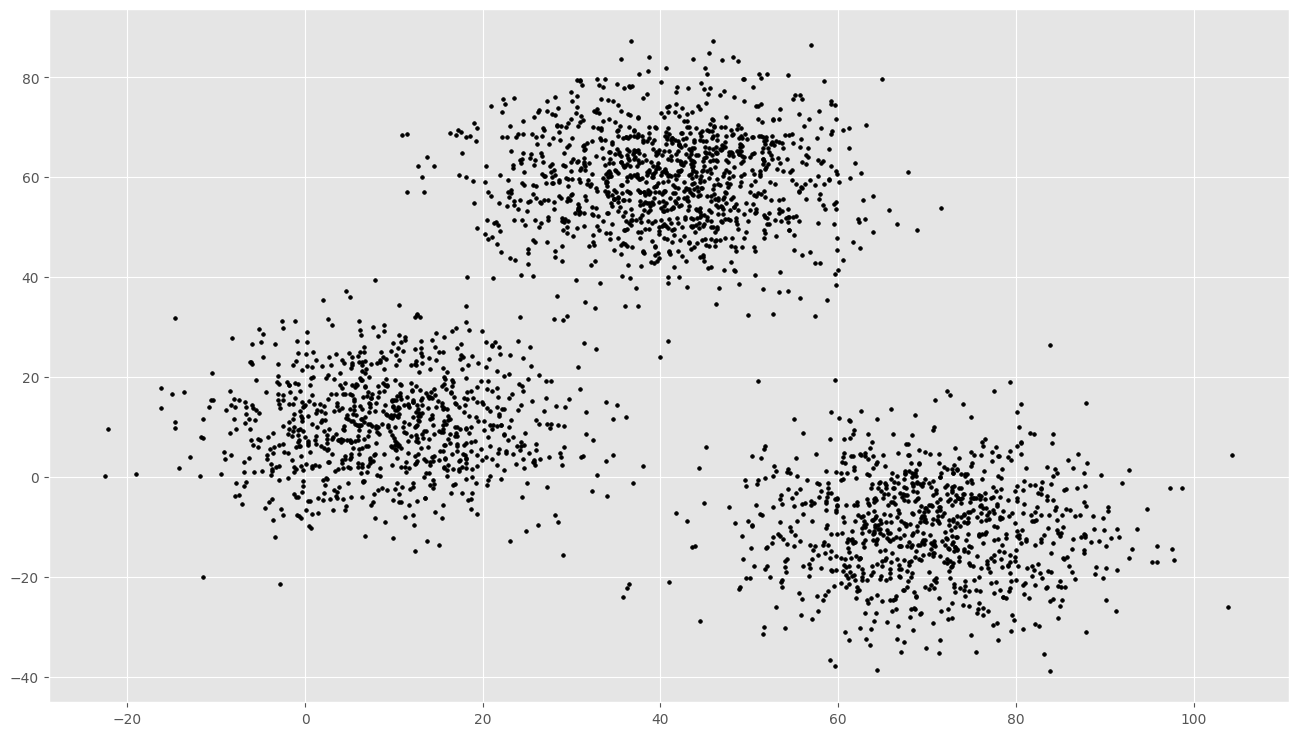

In [20]:
# Getting the values and plotting it
f1 = data['V1'].values
f2 = data['V2'].values
X = np.array(list(zip(f1, f2)))
plt.figure(figsize=(16,9))
plt.scatter(f1, f2, c='black', s=7)

In [21]:
len(X)
#X[0:5]

3000

In [22]:
# Euclidean Distance
def dist(a, b, ax=1):
    return np.linalg.norm(a - b, axis=ax)

In [23]:
# Number of clusters
k = 3
# X coordinates of random centroids
C_x = np.random.randint(0, np.max(X)-20, size=k)
# Y coordinates of random centroids
C_y = np.random.randint(0, np.max(X)-20, size=k)
C = np.array(list(zip(C_x, C_y)), dtype=np.float32)
print(C)

[[83. 82.]
 [78. 66.]
 [ 0. 60.]]


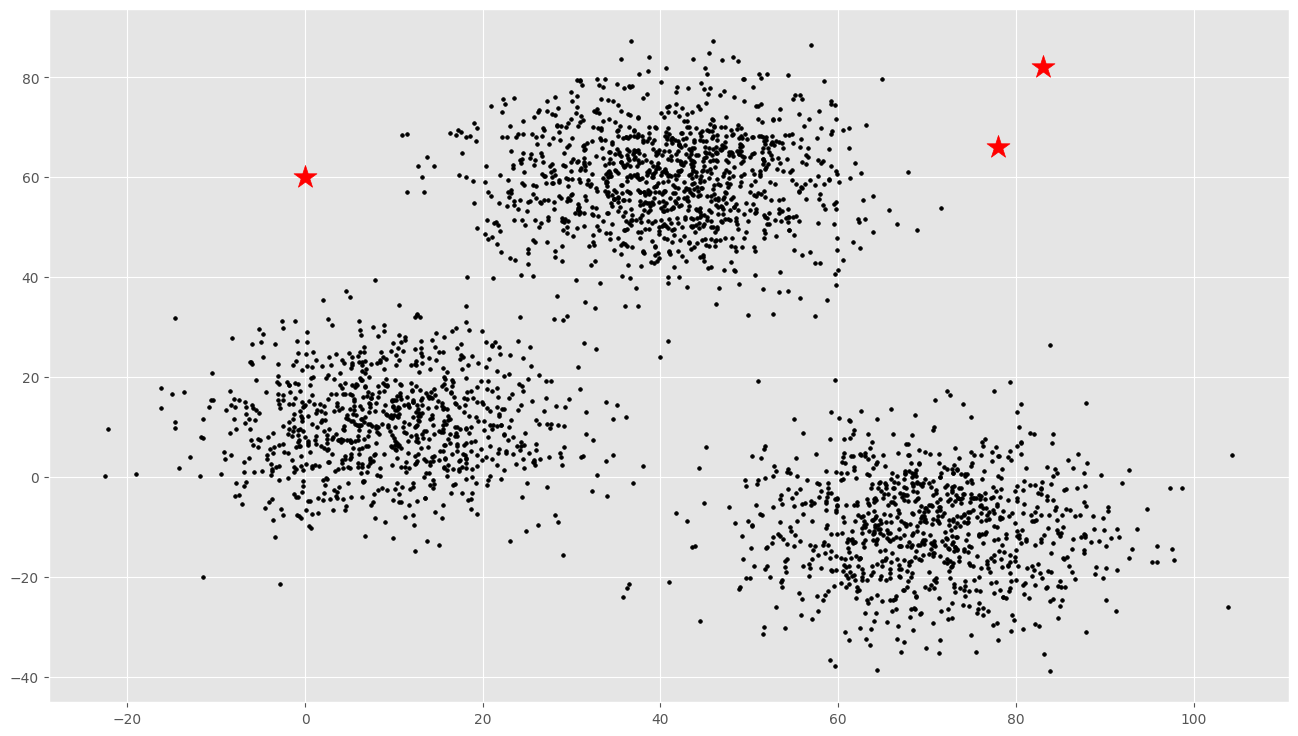

In [24]:
# Plotting along with the Centroids
plt.figure(figsize=(16,9))
plt.scatter(f1, f2, c='black', s=7)
plt.scatter(C_x, C_y, marker='*', s=300, c='r')

In [25]:
# To store the value of centroids when it updates
C_old = np.zeros(C.shape)

In [26]:
C_old

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [27]:
# Cluster Lables(0, 1, 2)
clusters = np.zeros(len(X))

In [28]:
clusters

array([0., 0., 0., ..., 0., 0., 0.], shape=(3000,))

In [29]:
def plotData(points,clusters,C):
    colors = ['r', 'g', 'b', 'y', 'c', 'm']
    fig, ax = plt.subplots()
    plt.figure(figsize=(16,9))
    for i in range(k):
            points = np.array([X[j] for j in range(len(X)) if clusters[j] == i])
            ax.scatter(points[:, 0], points[:, 1], s=7, c=colors[i])
    ax.scatter(C[:, 0], C[:, 1], marker='*', s=200, c='#050505')
    plt.show()

Distance is [117.53906401 102.75904264  63.27563787]
Distance is [92.83147684 78.28897823 47.71486762]
Distance is [110.84911364  96.7448985   52.6919667 ]
Distance is [98.66854347 84.46718375 46.92985203]
Distance is [99.12716442 83.49944642 62.14380179]
Distance is [77.19131914 63.65525909 36.97023736]
Distance is [98.52613031 83.11213818 59.21320337]
Distance is [104.8050209   90.84590627  47.88840601]
Distance is [104.77634233  89.22621419  64.06964076]
Distance is [116.94781079 101.99982944  64.58024288]
Distance is [94.16524231 80.87488608 37.5213022 ]
Distance is [106.16404327  92.68972281  44.70480732]
Distance is [109.18089079  94.48022734  57.16066023]
Distance is [127.71980626 112.7836701   72.10729598]
Distance is [107.39254308  91.83548752  65.62733599]
Distance is [98.37863311 85.32060697 37.44566898]
Distance is [102.50481521  87.82692597  53.23409706]
Distance is [114.89117247 100.45923676  58.19770767]
Distance is [92.1896966  79.4231458  32.90182179]
Distance is [120.

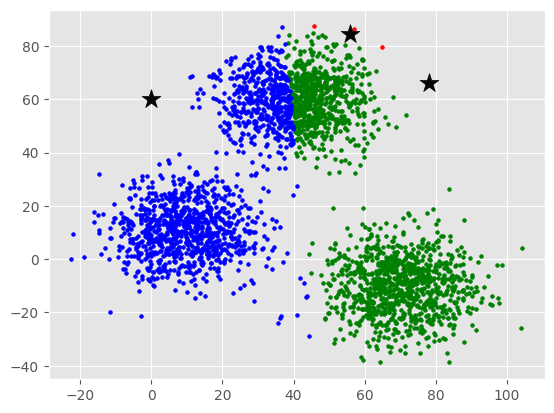

<Figure size 1600x900 with 0 Axes>

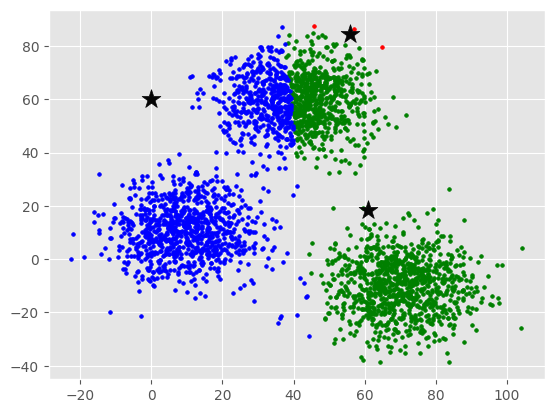

<Figure size 1600x900 with 0 Axes>

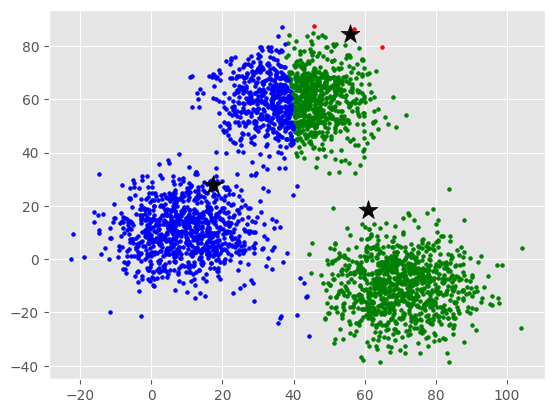

<Figure size 1600x900 with 0 Axes>

Distance is [102.97528541  62.83673326  34.59282402]
Distance is [78.54242501 43.19833787 11.97241387]
Distance is [94.70539533 60.99084702 26.17320654]
Distance is [83.21452824 50.09510974 14.76406742]
Distance is [88.07327814 40.57530697 25.95694804]
Distance is [61.36070695 39.31014586  7.96913869]
Distance is [86.69227577 41.6492458  23.24058884]
Distance is [88.5197585  56.6880867  19.99848479]
Distance is [93.18675453 46.18415866 28.92248694]
Distance is [102.89881385  61.25343975  34.79610672]
Distance is [76.82357004 52.18433966  9.29288409]
Distance is [88.74389139 60.72736141 21.10262917]
Distance is [94.65553456 55.8256513  26.45471973]
Distance is [113.34398535  71.32132425  44.92228278]
Distance is [95.73022138 48.50957073 30.96011731]
Distance is [80.38669146 56.80838326 13.93284345]
Distance is [88.16229296 50.18258549 20.38215924]
Distance is [99.448744   62.57622717 30.86211436]
Distance is [73.89075617 53.75193516  9.26889402]
Distance is [103.82619996  69.05675248  3

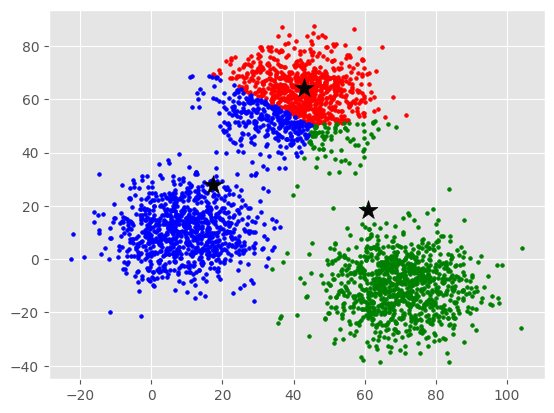

<Figure size 1600x900 with 0 Axes>

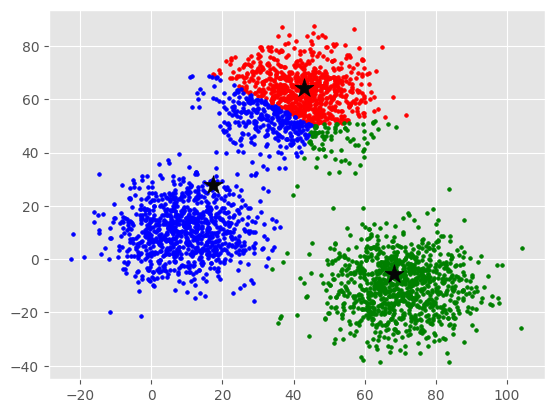

<Figure size 1600x900 with 0 Axes>

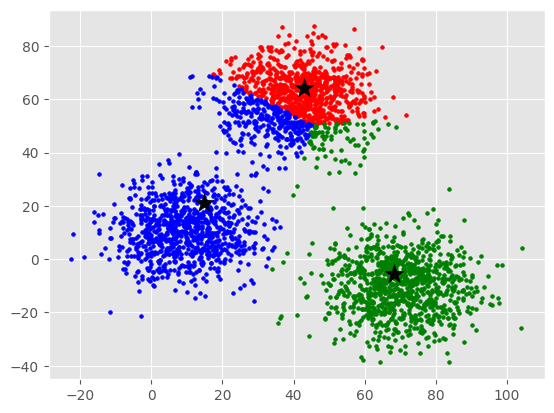

<Figure size 1600x900 with 0 Axes>

Distance is [78.99190985 66.33389899 27.48927381]
Distance is [54.6239304  54.79830147  6.07644139]
Distance is [70.75534802 68.52006273 19.50085577]
Distance is [59.22593195 60.65880769  7.66210045]
Distance is [64.70112198 45.40143948 20.48440894]
Distance is [37.38404116 58.08229728 14.34467596]
Distance is [63.13818586 47.87510833 17.51774171]
Distance is [64.57002741 66.16608414 13.43865903]
Distance is [69.62842896 49.35969991 22.5926462 ]
Distance is [78.93812639 64.14321966 27.6517251 ]
Distance is [52.96500467 66.07279475  6.32837882]
Distance is [64.94411059 71.11446078 15.61573481]
Distance is [70.68071066 61.70338164 19.31167476]
Distance is [89.35997625 72.08135368 37.83784559]
Distance is [72.13502833 50.78189466 24.42414439]
Distance is [56.6725002  70.00278272 10.65128462]
Distance is [64.20895472 58.08121089 13.27625633]
Distance is [75.46636159 68.04766908 23.92041881]
Distance is [50.21899603 69.01882121  9.76677396]
Distance is [79.90910646 74.43684774 28.8040513 ]


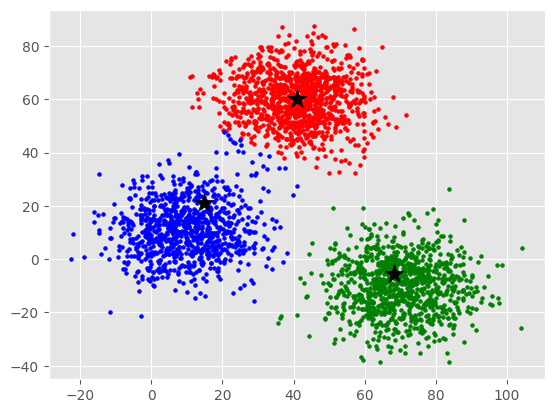

<Figure size 1600x900 with 0 Axes>

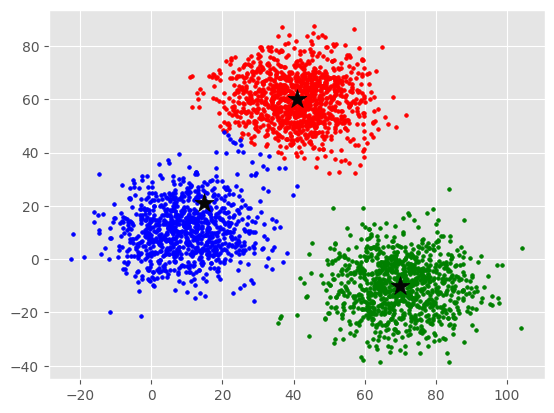

<Figure size 1600x900 with 0 Axes>

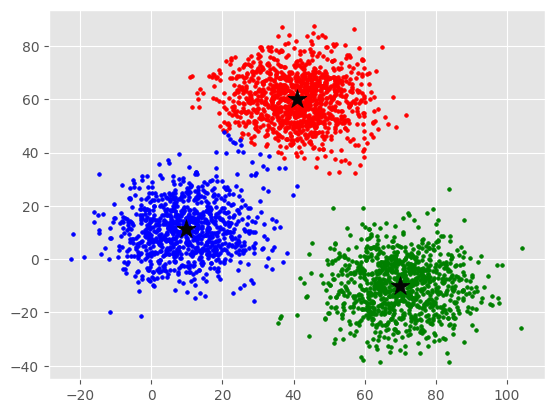

<Figure size 1600x900 with 0 Axes>

Distance is [74.25841862 68.19954982 16.47832143]
Distance is [49.87268063 58.08389047  9.25447052]
Distance is [66.08121517 71.01508313  9.62153346]
Distance is [54.50482496 63.7134124   3.36981078]
Distance is [60.01139745 47.91996984 16.38121224]
Distance is [32.64498466 62.20614322 25.20271924]
Distance is [58.41954761 50.5395772  13.43506679]
Distance is [59.8973824  68.98950247  5.26270555]
Distance is [64.90727779 51.50440726 15.5435119 ]
Distance is [74.19355768 65.93872666 16.70112639]
Distance is [48.35636602 69.52468698 12.34087294]
Distance is [60.35951653 74.01741347 10.25848082]
Distance is [65.94124293 64.03332203  8.36965026]
Distance is [84.62712846 73.38733535 26.83241856]
Distance is [67.40816555 52.73912107 16.45862981]
Distance is [52.13677457 73.32218022 12.74595031]
Distance is [59.46231487 60.78486385  3.79260383]
Distance is [70.76091105 70.21858597 13.1564594 ]
Distance is [45.71211539 72.62869564 16.92858822]
Distance is [75.25533845 76.51373417 18.69137043]


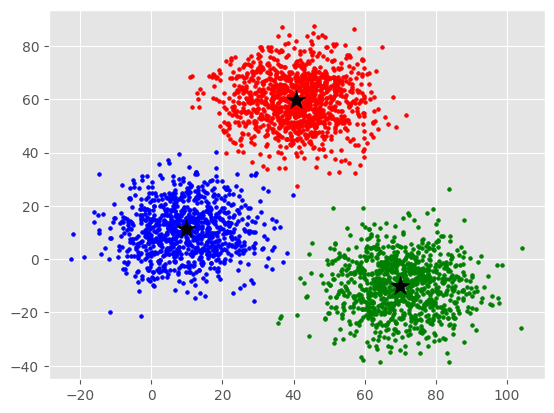

<Figure size 1600x900 with 0 Axes>

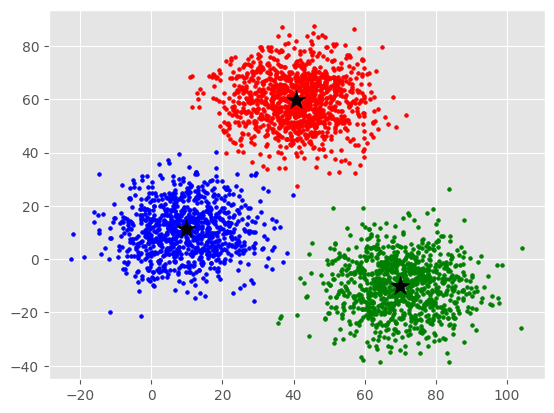

<Figure size 1600x900 with 0 Axes>

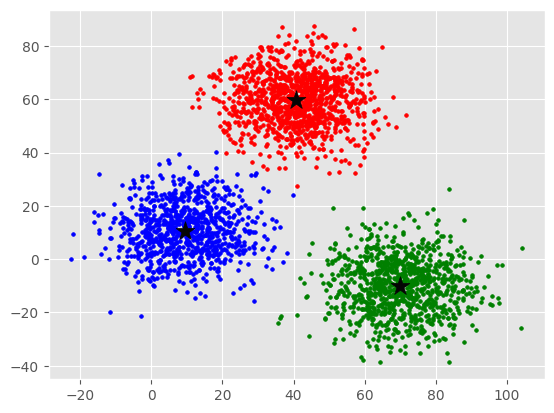

<Figure size 1600x900 with 0 Axes>

Distance is [73.87934394 68.19954982 15.80760074]
Distance is [49.49503631 58.08389047  9.85139225]
Distance is [65.70331046 71.01508313  9.06573413]
Distance is [54.12572377 63.7134124   4.03342888]
Distance is [59.64672415 47.91996984 16.39864152]
Distance is [32.26601359 62.20614322 25.87500573]
Distance is [58.05056743 50.5395772  13.49973597]
Distance is [59.519554   68.98950247  5.06156575]
Distance is [64.53784374 51.50440726 15.32136118]
Distance is [73.81490173 65.93872666 16.04592292]
Distance is [47.9815504  69.52468698 12.89211736]
Distance is [59.98581062 74.01741347 10.16925257]
Distance is [65.56231493 64.03332203  7.72140132]
Distance is [84.24804637 73.38733535 26.16051957]
Distance is [67.03776219 52.73912107 16.14063892]
Distance is [51.76592179 73.32218022 13.11737157]
Distance is [59.08382933 60.78486385  3.57201428]
Distance is [70.38204776 70.21858597 12.49770252]
Distance is [45.34314683 72.62869564 17.4625969 ]
Distance is [74.87820723 76.51373417 18.07984765]


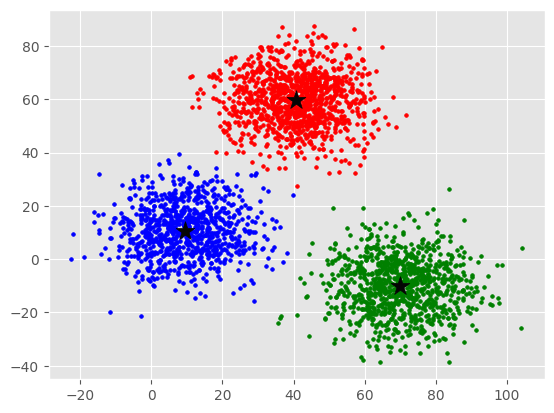

<Figure size 1600x900 with 0 Axes>

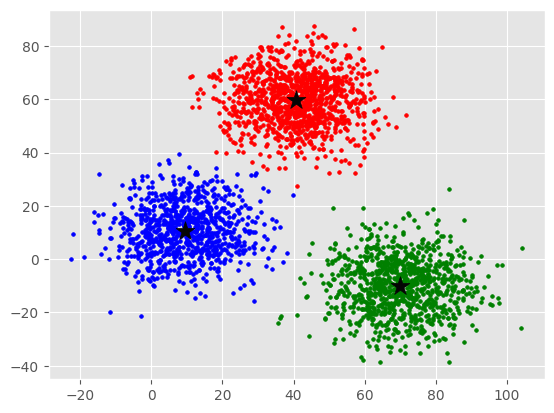

<Figure size 1600x900 with 0 Axes>

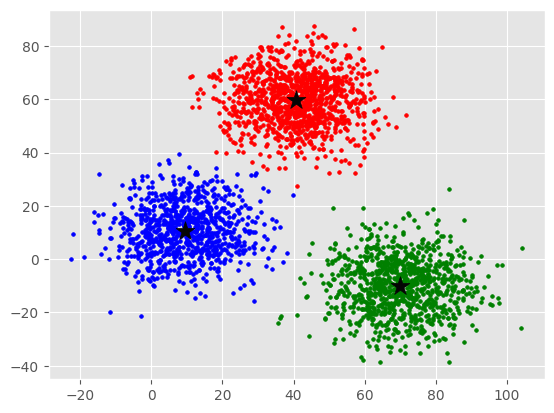

<Figure size 1600x900 with 0 Axes>

Distance is [73.85451097 68.19954982 15.77423498]
Distance is [49.47082289 58.08389047  9.87655484]
Distance is [65.67785057 71.01508313  9.04449964]
Distance is [54.10068569 63.7134124   4.06718942]
Distance is [59.62471906 47.91996984 16.39092101]
Distance is [32.24127715 62.20614322 25.90738833]
Distance is [58.02795894 50.5395772  13.49451771]
Distance is [59.4940811  68.98950247  5.06288854]
Distance is [64.5151667  51.50440726 15.30239348]
Distance is [73.79033923 65.93872666 16.01192699]
Distance is [47.95578328 69.52468698 12.92443247]
Distance is [59.95998531 74.01741347 10.17526601]
Distance is [65.53760733 64.03332203  7.6873747 ]
Distance is [84.22320384 73.38733535 26.12735736]
Distance is [67.01493762 52.73912107 16.11745451]
Distance is [51.73999904 73.32218022 13.14367477]
Distance is [59.05933917 60.78486385  3.55515062]
Distance is [70.35683763 70.21858597 12.46762422]
Distance is [45.31718732 72.62869564 17.49437871]
Distance is [74.8526366  76.51373417 18.05414327]


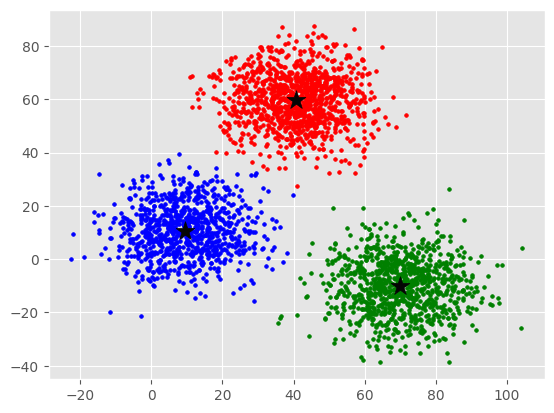

<Figure size 1600x900 with 0 Axes>

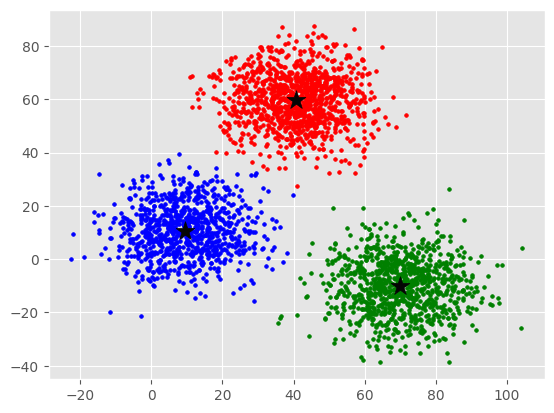

<Figure size 1600x900 with 0 Axes>

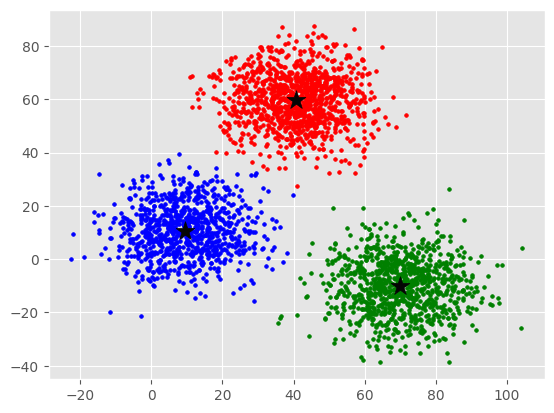

<Figure size 1600x900 with 0 Axes>

In [30]:
# Error func. - Distance between new centroids and old centroids
error = dist(C, C_old, None)
# Loop will run till the error becomes zero
while error != 0:
    # Assigning each value to its closest cluster
    for i in range(len(X)):
        distances = dist(X[i], C)
        print("Distance is",distances)
        cluster = np.argmin(distances)
#         print("Cluster is",cluster)
        clusters[i] = cluster
    # Storing the old centroid values
    C_old = deepcopy(C)
    # Finding the new centroids by taking the average value
    for i in range(k):
        points = [X[j] for j in range(len(X)) if clusters[j] == i]
#         print(points)
        C[i] = np.mean(points, axis=0)
        plotData(points, clusters, C)
    error = dist(C, C_old, None)

In [15]:
C

array([[  9.478045,  10.686052],
       [ 69.92419 , -10.119641],
       [ 40.683628,  59.715893]], dtype=float32)